In [1]:
# --- Cell 1: Import Libraries and Load Data ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('insider_threat_clean_dataset.csv')
print("Dataset shape:", df.shape)

# Define feature columns (use the corrected list from preprocess.ipynb)
feature_columns = [
    'employee_seniority_years', 'is_contractor', 'employee_classification',
    'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history',
    'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned',
    'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level',
    'num_entries', 'num_unique_campus', 'late_exit_flag', 'entry_during_weekend'
]
target_column = 'is_malicious'

X = df[feature_columns]
y = df[target_column]

print("\nSelected Features (confirmed):")
for feature in feature_columns:
    print(f"  - {feature}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape[0]} records")
print(f"Test set size: {X_test.shape[0]} records")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Original training data shape: {X_train_scaled.shape}")
print(f"Resampled training data shape: {X_train_resampled.shape}")

Dataset shape: (118614, 22)

Selected Features (confirmed):
  - employee_seniority_years
  - is_contractor
  - employee_classification
  - has_foreign_citizenship
  - has_criminal_record
  - has_medical_history
  - total_printed_pages
  - num_printed_pages_off_hours
  - total_files_burned
  - burned_from_other
  - is_abroad
  - trip_day_number
  - hostility_country_level
  - num_entries
  - num_unique_campus
  - late_exit_flag
  - entry_during_weekend

Training set size: 83029 records
Test set size: 35585 records
Original training data shape: (83029, 17)
Resampled training data shape: (157118, 17)


In [2]:
# --- Cell 2: Train the Random Forest Model ---
# Initialize the model
# n_estimators=100 means 100 decision trees; random_state ensures reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

print("Model training complete.")

Model training complete.


=== Model Performance ===
Accuracy:  0.9561
Precision: 0.5792
Recall:    0.6759
F1-Score:  0.6238
AUC-ROC:   0.9176

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     33669
           1       0.58      0.68      0.62      1916

    accuracy                           0.96     35585
   macro avg       0.78      0.82      0.80     35585
weighted avg       0.96      0.96      0.96     35585



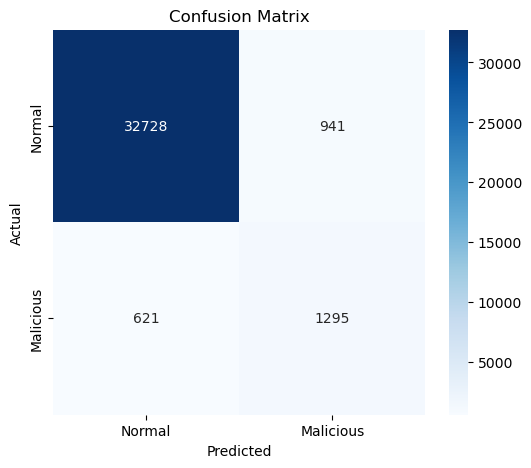

In [3]:
# --- Cell 3: Evaluate the Model ---
# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Model Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Malicious'], yticklabels=['Normal', 'Malicious'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [4]:
# --- Cell 2.5: Train Multiple Models and Compare ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest (Current)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Store results
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_resampled, y_train_resampled)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

# Compare results
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

=== Logistic Regression ===
Accuracy:  0.8669
Precision: 0.2494
Recall:    0.7323
F1-Score:  0.3720

=== Decision Tree ===
Accuracy:  0.9494
Precision: 0.5266
Recall:    0.6039
F1-Score:  0.5626

=== Random Forest (Current) ===
Accuracy:  0.9561
Precision: 0.5792
Recall:    0.6759
F1-Score:  0.6238


=== Model Comparison ===
                  Model  Accuracy  Precision   Recall  F1-Score
    Logistic Regression  0.866910   0.249378 0.732255  0.372050
          Decision Tree  0.949445   0.526627 0.603862  0.562606
Random Forest (Current)  0.956105   0.579159 0.675887  0.623796


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}
Best cross-validation F1: 0.9656033090427508

=== Tuned Random Forest Performance ===
Accuracy:  0.9580
Precision: 0.5952
Recall:    0.6868
F1-Score:  0.6378
AUC-ROC:   0.9267


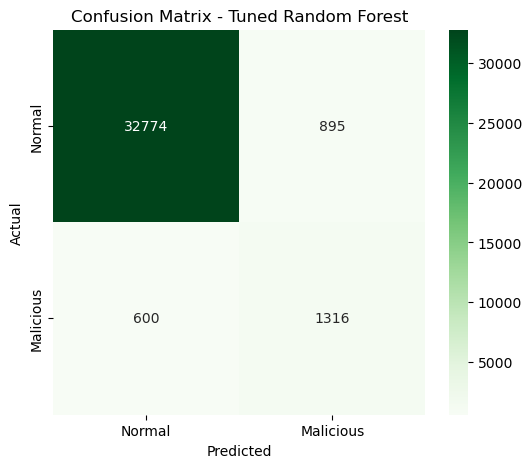

In [5]:
# --- Cell 2.6: Hyperparameter Tuning for Random Forest ---
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]  # helps with imbalanced classes
}

# Base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search (use 3-fold CV to save time)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_pred_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_best = roc_auc_score(y_test, y_pred_proba_best)

print("\n=== Tuned Random Forest Performance ===")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall:    {rec_best:.4f}")
print(f"F1-Score:  {f1_best:.4f}")
print(f"AUC-ROC:   {roc_best:.4f}")

# Confusion Matrix for tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Malicious'], yticklabels=['Normal', 'Malicious'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
import sys
print(sys.executable)
!{sys.executable} -m pip install xgboost

C:\Users\Mash\anaconda3\python.exe
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [11]:
import sys
print(sys.executable)

import xgboost
print("XGBoost version:", xgboost.__version__)

C:\Users\Mash\anaconda3\python.exe
XGBoost version: 3.2.0


Training XGBoost model...


C:\Users\Mash\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:50:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Performance ===
Accuracy:  0.8085
Precision: 0.2101
Recall:    0.9264
F1-Score:  0.3425
AUC-ROC:   0.9532


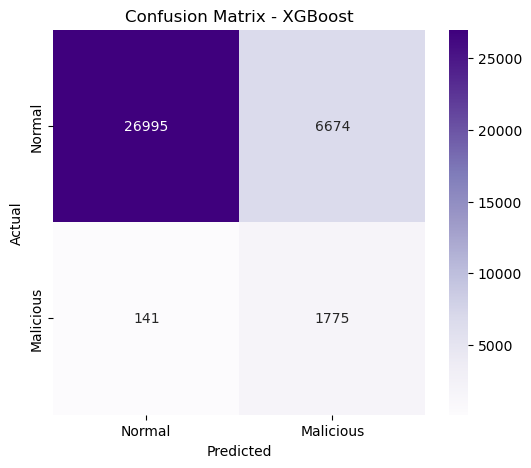


=== Top 10 Most Important Features (XGBoost) ===
                    Feature  Importance
         total_files_burned    0.140856
                  is_abroad    0.108072
          burned_from_other    0.085720
          num_unique_campus    0.081956
num_printed_pages_off_hours    0.074228
       entry_during_weekend    0.073440
    hostility_country_level    0.069351
        total_printed_pages    0.066439
        has_criminal_record    0.056811
                num_entries    0.055042


In [12]:
# --- Cell 3: XGBoost Model ---
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost with parameters optimized for imbalanced data
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=8,  # Helps with imbalanced data (negatives/positives ratio approx 17:1)
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train the model
print("Training XGBoost model...")
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n=== XGBoost Performance ===")
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"AUC-ROC:   {roc_xgb:.4f}")

# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Malicious'], yticklabels=['Normal', 'Malicious'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance from XGBoost
importance_df_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Top 10 Most Important Features (XGBoost) ===")
print(importance_df_xgb.head(10).to_string(index=False))


=== COMPLETE MODEL COMPARISON ===
                   Model  Accuracy  Precision   Recall  F1-Score
     Logistic Regression  0.866900   0.249400 0.732300  0.372000
           Decision Tree  0.949400   0.526600 0.603900  0.562600
Random Forest (Original)  0.956100   0.579200 0.675900  0.623800
   Random Forest (Tuned)  0.958000   0.595200 0.686800  0.637800
                 XGBoost  0.808487   0.210084 0.926409  0.342499


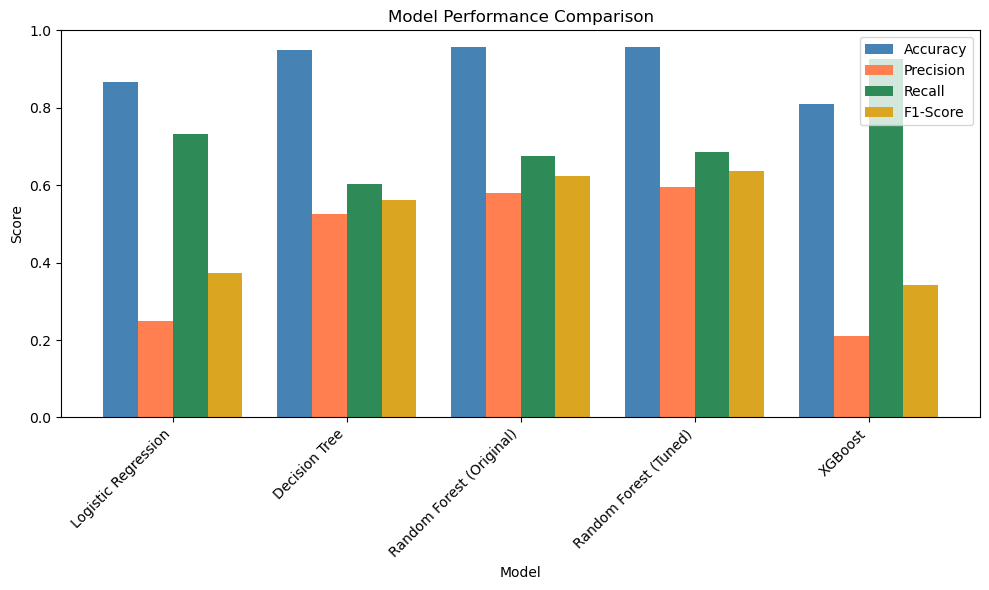

In [13]:
# --- Cell 3.5: Full Model Comparison ---
# Collect all results
all_results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': 0.8669, 'Precision': 0.2494, 'Recall': 0.7323, 'F1-Score': 0.3720},
    {'Model': 'Decision Tree', 'Accuracy': 0.9494, 'Precision': 0.5266, 'Recall': 0.6039, 'F1-Score': 0.5626},
    {'Model': 'Random Forest (Original)', 'Accuracy': 0.9561, 'Precision': 0.5792, 'Recall': 0.6759, 'F1-Score': 0.6238},
    {'Model': 'Random Forest (Tuned)', 'Accuracy': 0.9580, 'Precision': 0.5952, 'Recall': 0.6868, 'F1-Score': 0.6378},
    {'Model': 'XGBoost', 'Accuracy': acc_xgb, 'Precision': prec_xgb, 'Recall': rec_xgb, 'F1-Score': f1_xgb}
])

print("\n=== COMPLETE MODEL COMPARISON ===")
print(all_results.to_string(index=False))

# Visual comparison
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(all_results['Model']))
width = 0.2

ax.bar(x - width*1.5, all_results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - width/2, all_results['Precision'], width, label='Precision', color='coral')
ax.bar(x + width/2, all_results['Recall'], width, label='Recall', color='seagreen')
ax.bar(x + width*1.5, all_results['F1-Score'], width, label='F1-Score', color='goldenrod')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [14]:
# --- Cell 4: Save the Best Model (Choose based on F1-score) ---
import json

# Compare F1-scores and choose the best
model_f1_scores = {
    'Random Forest (Tuned)': f1_best if 'f1_best' in dir() else 0.6378,
    'XGBoost': f1_xgb
}

best_model_name = max(model_f1_scores, key=model_f1_scores.get)
print(f"\nBest model based on F1-score: {best_model_name} (F1 = {model_f1_scores[best_model_name]:.4f})")

# Select the best model
if best_model_name == 'XGBoost':
    final_model = xgb_model
    print("Saving XGBoost as the final model")
else:
    final_model = best_rf
    print("Saving Tuned Random Forest as the final model")

final_scaler = scaler

# Save
joblib.dump(final_model, 'insider_threat_model.pkl')
joblib.dump(final_scaler, 'scaler.pkl')
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print("\nFiles saved successfully:")
print("  - insider_threat_model.pkl")
print("  - scaler.pkl")
print("  - feature_columns.json")


Best model based on F1-score: Random Forest (Tuned) (F1 = 0.6378)
Saving Tuned Random Forest as the final model

Files saved successfully:
  - insider_threat_model.pkl
  - scaler.pkl
  - feature_columns.json
